<a href="https://colab.research.google.com/github/AlphaArcturus/SIT770-NLP-HD/blob/main/Self_Consistency_Prompt_Ensembling_for_Temporal_QA_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U transformers accelerate pandas matplotlib tqdm datasets statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.

In [2]:
import os
import re
import ast
import math
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter
from datasets import load_dataset, concatenate_datasets
from transformers import AutoTokenizer, AutoModelForCausalLM
from statsmodels.stats.contingency_tables import mcnemar

In [3]:
# ============================================================
# Experiment configuration
# ============================================================

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

N_SAMPLE = 200
RANDOM_SEED = 42
CONTEXT_WINDOW = 900
MAX_ANSWER_WORDS = 8

# Set this to False if you want to force a completely fresh run.
RESUME_FROM_CSV = True

print("Model:", MODEL_NAME)
print("Sample size:", N_SAMPLE)

Model: Qwen/Qwen2.5-1.5B-Instruct
Sample size: 200


In [6]:
# ============================================================
# Load Qwen model
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True
)

print("Loaded:", MODEL_NAME)
print("CUDA available:", torch.cuda.is_available())
print("Model device:", model.device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-1.5B-Instruct
CUDA available: True
Model device: cuda:0


In [7]:
# ============================================================
# Load TimeQA dataset
# ============================================================

raw_dataset = load_dataset("hugosousa/TimeQA")

print(raw_dataset)

all_splits = []
for split_name in raw_dataset.keys():
    print("Split:", split_name, "Rows:", len(raw_dataset[split_name]))
    all_splits.append(raw_dataset[split_name])

raw_all = concatenate_datasets(all_splits)

print("Total rows:", len(raw_all))
print("Columns:", raw_all.column_names)
print("Example row:")
print(raw_all[0])

README.md:   0%|          | 0.00/449 [00:00<?, ?B/s]

train.json:   0%|          | 0.00/300M [00:00<?, ?B/s]

dev.json:   0%|          | 0.00/65.5M [00:00<?, ?B/s]

test.json:   0%|          | 0.00/64.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28989 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6108 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6075 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['targets', 'level', 'question', 'idx', 'context'],
        num_rows: 28989
    })
    validation: Dataset({
        features: ['targets', 'level', 'question', 'idx', 'context'],
        num_rows: 6108
    })
    test: Dataset({
        features: ['targets', 'level', 'question', 'idx', 'context'],
        num_rows: 6075
    })
})
Split: train Rows: 28989
Split: validation Rows: 6108
Split: test Rows: 6075
Total rows: 41172
Columns: ['targets', 'level', 'question', 'idx', 'context']
Example row:
{'targets': ['Ulster Unionist MP for South Antrim'], 'level': 'easy', 'question': 'Which position did Knox Cunningham hold from May 1955 to Apr 1956?', 'idx': '/wiki/Knox_Cunningham#P39#0', 'context': 'Knox Cunningham Sir Samuel Knox Cunningham , 1st Baronet , QC ( 3 April 1909 – 29 July 1976 ) , was a Northern Irish barrister , businessman and politician . As an Ulster Unionist politician at a time when the Unionists were part of the Conserva

In [8]:
# ============================================================
# Standardise TimeQA columns
# ============================================================

question_col = "question"
context_col = "context"
answer_col = "targets"

def parse_answers(ans):
    if ans is None:
        return []

    if isinstance(ans, list):
        return [str(a).strip() for a in ans if str(a).strip()]

    if isinstance(ans, str):
        ans = ans.strip()

        if not ans:
            return []

        if ans.startswith("[") and ans.endswith("]"):
            try:
                parsed = ast.literal_eval(ans)
                if isinstance(parsed, list):
                    return [str(a).strip() for a in parsed if str(a).strip()]
            except Exception:
                pass

        return [ans]

    return [str(ans).strip()]

rows = []

for i, item in enumerate(raw_all):
    question = str(item[question_col]).strip()
    context = str(item[context_col]).strip() if item[context_col] is not None else ""
    answers = parse_answers(item[answer_col])

    if not question or len(answers) == 0:
        continue

    rows.append({
        "source_id": i,
        "idx": item.get("idx", ""),
        "level": item.get("level", ""),
        "question": question,
        "context": context,
        "answers": answers,
        "primary_answer": answers[0]
    })

df_all = pd.DataFrame(rows)

print("Usable rows:", len(df_all))
df_all.head()

Usable rows: 35638


,source_id,idx,level,question,context,answers,primary_answer
0,0,/wiki/Knox_Cunningham#P39#0,easy,Which position did Knox Cunningham hold from M...,"Knox Cunningham Sir Samuel Knox Cunningham , 1...",[Ulster Unionist MP for South Antrim],Ulster Unionist MP for South Antrim
1,1,/wiki/Knox_Cunningham#P39#1,easy,Which position did Knox Cunningham hold from A...,"Knox Cunningham Sir Samuel Knox Cunningham , 1...",[delegate to the Council of Europe and Western...,delegate to the Council of Europe and Western ...
2,2,/wiki/Knox_Cunningham#P39#2,easy,Which position did Knox Cunningham hold from A...,"Knox Cunningham Sir Samuel Knox Cunningham , 1...",[delegate to the Council of Europe and Western...,delegate to the Council of Europe and Western ...
3,3,/wiki/Knox_Cunningham#P39#3,easy,Which position did Knox Cunningham hold from O...,"Knox Cunningham Sir Samuel Knox Cunningham , 1...",[Parliamentary Private Secretary],Parliamentary Private Secretary
4,6,/wiki/Anna_Karina#P26#1,easy,Who was the spouse of Anna Karina from 1968 to...,Anna Karina Anna Karina ( born Hanne Karin Bay...,[Pierre Fabre],Pierre Fabre


In [9]:
# ============================================================
# Filter and sample benchmark subset
# ============================================================

def answer_is_short(answers):
    return any(len(str(a).split()) <= MAX_ANSWER_WORDS for a in answers)

def find_answer_in_context(context, answers):
    context_lower = str(context).lower()

    for ans in answers:
        ans_lower = str(ans).lower().strip()

        if ans_lower and ans_lower in context_lower:
            return ans

    return None

def extract_answer_window(context, answer, window=900):
    context = str(context)
    context_lower = context.lower()
    answer_lower = str(answer).lower()

    idx = context_lower.find(answer_lower)

    if idx == -1:
        return context[:window]

    start = max(0, idx - window // 2)
    end = min(len(context), idx + len(answer) + window // 2)

    return context[start:end]

df_filtered = df_all.copy()

df_filtered = df_filtered[df_filtered["answers"].apply(answer_is_short)].copy()

df_filtered["matched_answer"] = df_filtered.apply(
    lambda r: find_answer_in_context(r["context"], r["answers"]),
    axis=1
)

df_filtered = df_filtered[df_filtered["matched_answer"].notna()].copy()

df_filtered["answer_window_context"] = df_filtered.apply(
    lambda r: extract_answer_window(
        r["context"],
        r["matched_answer"],
        CONTEXT_WINDOW
    ),
    axis=1
)

print("Filtered examples available:", len(df_filtered))
print("Difficulty distribution:")
print(df_filtered["level"].value_counts())

if len(df_filtered) < N_SAMPLE:
    print("Warning: fewer filtered examples than requested. Using all available examples.")
    df_sample = df_filtered.copy()
else:
    df_sample = df_filtered.sample(n=N_SAMPLE, random_state=RANDOM_SEED).copy()

df_sample = df_sample.reset_index(drop=True)
df_sample["id"] = np.arange(1, len(df_sample) + 1)

df_base = df_sample[
    [
        "id",
        "source_id",
        "idx",
        "level",
        "question",
        "answer_window_context",
        "context",
        "answers",
        "primary_answer",
        "matched_answer"
    ]
].copy()

df_base = df_base.rename(columns={
    "answer_window_context": "context",
    "context": "full_context"
})

df_base.to_csv("timeqa_answer_window_subset.csv", index=False)

print("Final benchmark subset:", len(df_base))
df_base.head()

Filtered examples available: 34920
Difficulty distribution:
level
easy    17460
hard    17460
Name: count, dtype: int64
Final benchmark subset: 200


,id,source_id,idx,level,question,context,full_context,answers,primary_answer,matched_answer
0,1,1638,/wiki/George_Ryan#P39#2,easy,What was the position of George Ryan from 1991...,began his political career by serving on the ...,George Ryan George Homer Ryan ( born February ...,[Secretary of State],Secretary of State,Secretary of State
1,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,Astrid Grotelüschen Astrid Katharina Josefine ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy
2,3,17211,/wiki/Rachida_Dati#P39#2,hard,Rachida Dati took which position between Mar 2...,an EU common list of safe countries of origin...,Rachida Dati Rachida Dati ( ; born 27 November...,[legal adviser],legal adviser,legal adviser
3,4,38524,/wiki/Ludwig_Mond#P937#0,easy,Where did Ludwig Mond work from 1862 to 1864?,"ociety in 1891 . Abroad , he was elected to me...",Ludwig Mond Ludwig Mond ( 7 March 1839 – 11 De...,[Great Britain],Great Britain,Great Britain
4,5,5892,/wiki/Manuel_Valls#P26#0,easy,Who was Manuel Valls 's spouse from 1987 to 2007?,ced by his deputy Carlos Da Silva from 2012 to...,"Manuel Valls Manuel Carlos Valls Galfetti ( , ...",[Nathalie Soulié],Nathalie Soulié,Nathalie Soulié


In [10]:
# ============================================================
# Text normalisation and answer scoring
# ============================================================

def norm_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def token_f1(pred, gold):
    pred_tokens = norm_text(pred).split()
    gold_tokens = norm_text(gold).split()

    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)

def parse_answers_from_cell(x):
    if isinstance(x, list):
        return x

    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            return [x]

    return [str(x)]

def is_correct_prediction(output, answers):
    answers = parse_answers_from_cell(answers)
    out_norm = norm_text(output)

    for ans in answers:
        ans_norm = norm_text(ans)

        if not ans_norm:
            continue

        if ans_norm == out_norm:
            return True

        if ans_norm in out_norm:
            return True

        if out_norm in ans_norm and len(out_norm.split()) >= 2:
            return True

        if token_f1(output, ans) >= 0.80:
            return True

    return False

def canonical_model_output(output):
    out = norm_text(output)

    prefixes = [
        "the answer is",
        "answer is",
        "it is",
        "the correct answer is"
    ]

    for p in prefixes:
        if out.startswith(p):
            out = out[len(p):].strip()

    return out

def answer_in_text(answers, text):
    answers = parse_answers_from_cell(answers)
    text_norm = norm_text(text)

    for ans in answers:
        ans_norm = norm_text(ans)
        if ans_norm and ans_norm in text_norm:
            return True

    return False

In [11]:
# ============================================================
# Text normalisation and answer scoring
# ============================================================

def norm_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def token_f1(pred, gold):
    pred_tokens = norm_text(pred).split()
    gold_tokens = norm_text(gold).split()

    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)

def parse_answers_from_cell(x):
    if isinstance(x, list):
        return x

    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            return [x]

    return [str(x)]

def is_correct_prediction(output, answers):
    answers = parse_answers_from_cell(answers)
    out_norm = norm_text(output)

    for ans in answers:
        ans_norm = norm_text(ans)

        if not ans_norm:
            continue

        if ans_norm == out_norm:
            return True

        if ans_norm in out_norm:
            return True

        if out_norm in ans_norm and len(out_norm.split()) >= 2:
            return True

        if token_f1(output, ans) >= 0.80:
            return True

    return False

def canonical_model_output(output):
    out = norm_text(output)

    prefixes = [
        "the answer is",
        "answer is",
        "it is",
        "the correct answer is"
    ]

    for p in prefixes:
        if out.startswith(p):
            out = out[len(p):].strip()

    return out

def answer_in_text(answers, text):
    answers = parse_answers_from_cell(answers)
    text_norm = norm_text(text)

    for ans in answers:
        ans_norm = norm_text(ans)
        if ans_norm and ans_norm in text_norm:
            return True

    return False

In [13]:
# ============================================================
# Model inference functions
# ============================================================

def run_qwen(prompt, system_message, max_new_tokens=40):
    messages = [
        {
            "role": "system",
            "content": system_message
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

def ask_qwen_direct(prompt, max_new_tokens=30):
    return run_qwen(
        prompt=prompt,
        system_message=(
            "You are a factual question answering system. "
            "Use the provided context and answer with only the shortest correct answer."
        ),
        max_new_tokens=max_new_tokens
    )

def ask_qwen_evidence_guided(prompt, max_new_tokens=120):
    return run_qwen(
        prompt=prompt,
        system_message=(
            "You are a careful temporal question answering system. "
            "Use the provided context. Identify relevant evidence first, "
            "then give a short final answer."
        ),
        max_new_tokens=max_new_tokens
    )

In [14]:
# ============================================================
# Direct baseline
# ============================================================

def make_direct_prompt(question, context):
    return f"""
Context:
{context}

Question:
{question}

Answer with only the shortest factual answer from the context.
Answer:
"""

DIRECT_OUTPUT_FILE = "timeqa_direct_baseline_outputs.csv"

if RESUME_FROM_CSV and os.path.exists(DIRECT_OUTPUT_FILE):
    df_direct = pd.read_csv(DIRECT_OUTPUT_FILE)
    completed_ids = set(df_direct["id"].tolist())
    direct_rows = df_direct.to_dict("records")
    print("Loaded existing direct baseline outputs:", len(direct_rows))
else:
    completed_ids = set()
    direct_rows = []

for _, row in tqdm(df_base.iterrows(), total=len(df_base)):
    qid = row["id"]

    if qid in completed_ids:
        continue

    prompt = make_direct_prompt(row["question"], row["context"])
    raw_output = ask_qwen_direct(prompt)

    direct_rows.append({
        "id": row["id"],
        "source_id": row["source_id"],
        "idx": row["idx"],
        "level": row["level"],
        "question": row["question"],
        "context": row["context"],
        "answers": row["answers"],
        "primary_answer": row["primary_answer"],
        "matched_answer": row["matched_answer"],
        "direct_output": raw_output
    })

    if len(direct_rows) % 20 == 0:
        pd.DataFrame(direct_rows).to_csv(DIRECT_OUTPUT_FILE, index=False)

df_direct = pd.DataFrame(direct_rows)
df_direct["direct_correct"] = df_direct.apply(
    lambda r: is_correct_prediction(r["direct_output"], r["answers"]),
    axis=1
)

df_direct.to_csv("timeqa_direct_baseline_scored.csv", index=False)

direct_acc = df_direct["direct_correct"].mean()

print("Direct baseline accuracy:", direct_acc)
print("Direct baseline accuracy (%):", direct_acc * 100)

df_direct[["id", "question", "primary_answer", "direct_output", "direct_correct"]].head(20)

100%|██████████| 200/200 [01:09<00:00,  2.86it/s]


Direct baseline accuracy: 0.505
Direct baseline accuracy (%): 50.5


,id,question,primary_answer,direct_output,direct_correct
0,1,What was the position of George Ryan from 1991...,Secretary of State,Secretary of State,True
1,2,What organization or association or team did A...,Committee on Economic Affairs and Energy,Subcommittee on Regional Economic Policy and E...,False
2,3,Rachida Dati took which position between Mar 2...,legal adviser,Member of the European Parliament,False
3,4,Where did Ludwig Mond work from 1862 to 1864?,Great Britain,Germany,False
4,5,Who was Manuel Valls 's spouse from 1987 to 2007?,Nathalie Soulié,Nathalie Soulié,True
5,6,Who was the rector of Technical University Leu...,Herbert Dallmann,Herbert Dallmann,True
6,7,Which team did Mohd Zaquan Adha Abdul Radzak p...,Sembilan FA,Negeri Sembilan FA,True
7,8,Who was the spouse of Toomas Hendrik Ilves fro...,Ieva Kupce,Ieva Kupce,True
8,9,Which position did Shahid Malik hold from Oct ...,Under Secretary of State,Minister of Justice,False
9,10,Steven Ozment went to which school in 1960?,Drew Theological School,University of Arkansas,False


In [15]:
# ============================================================
# Six semantically equivalent prompt variants
# ============================================================

def make_variants(question, context):
    context_block = f"Context:\n{context}\n\n"

    return {
        "Original Prompt":
            f"{context_block}Question: {question}\nAnswer:",

        "Instruction Framing":
            f"{context_block}Give only the short factual answer from the context.\nQuestion: {question}\nAnswer:",

        "Temporal Rephrasing":
            f"{context_block}Considering the time period specified in the question, answer using the context.\nQuestion: {question}\nAnswer:",

        "Syntactic Reformulation":
            f"{context_block}What is the correct answer to this time-specific question based on the context?\n{question}\nAnswer:",

        "Contextual Framing":
            f"{context_block}Use only the information relevant to the year, date, or event mentioned in the context.\nQuestion: {question}\nAnswer:",

        "Concise Temporal Prompt":
            f"{context_block}Answer briefly from the context: {question}"
    }

prompt_rows = []

for _, row in df_base.iterrows():
    variants = make_variants(row["question"], row["context"])

    for variant_type, prompt in variants.items():
        prompt_rows.append({
            "id": row["id"],
            "source_id": row["source_id"],
            "idx": row["idx"],
            "level": row["level"],
            "variant_type": variant_type,
            "prompt": prompt,
            "question": row["question"],
            "context": row["context"],
            "answers": row["answers"],
            "primary_answer": row["primary_answer"],
            "matched_answer": row["matched_answer"]
        })

df_prompts = pd.DataFrame(prompt_rows)
df_prompts.to_csv("timeqa_prompt_variants.csv", index=False)

print("Total prompts:", len(df_prompts))
print("Prompt variants:", df_prompts["variant_type"].unique())

df_prompts.head(12)

Total prompts: 1200
Prompt variants: <ArrowStringArray>
[        'Original Prompt',     'Instruction Framing',
     'Temporal Rephrasing', 'Syntactic Reformulation',
      'Contextual Framing', 'Concise Temporal Prompt']
Length: 6, dtype: str


,id,source_id,idx,level,variant_type,prompt,question,context,answers,primary_answer,matched_answer
0,1,1638,/wiki/George_Ryan#P39#2,easy,Original Prompt,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
1,1,1638,/wiki/George_Ryan#P39#2,easy,Instruction Framing,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
2,1,1638,/wiki/George_Ryan#P39#2,easy,Temporal Rephrasing,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
3,1,1638,/wiki/George_Ryan#P39#2,easy,Syntactic Reformulation,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
4,1,1638,/wiki/George_Ryan#P39#2,easy,Contextual Framing,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
5,1,1638,/wiki/George_Ryan#P39#2,easy,Concise Temporal Prompt,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
6,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,Original Prompt,Context:\ness than 700 votes ahead and thus en...,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy
7,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,Instruction Framing,Context:\ness than 700 votes ahead and thus en...,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy
8,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,Temporal Rephrasing,Context:\ness than 700 votes ahead and thus en...,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy
9,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,Syntactic Reformulation,Context:\ness than 700 votes ahead and thus en...,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy


In [16]:
# ============================================================
# Six semantically equivalent prompt variants
# ============================================================

def make_variants(question, context):
    context_block = f"Context:\n{context}\n\n"

    return {
        "Original Prompt":
            f"{context_block}Question: {question}\nAnswer:",

        "Instruction Framing":
            f"{context_block}Give only the short factual answer from the context.\nQuestion: {question}\nAnswer:",

        "Temporal Rephrasing":
            f"{context_block}Considering the time period specified in the question, answer using the context.\nQuestion: {question}\nAnswer:",

        "Syntactic Reformulation":
            f"{context_block}What is the correct answer to this time-specific question based on the context?\n{question}\nAnswer:",

        "Contextual Framing":
            f"{context_block}Use only the information relevant to the year, date, or event mentioned in the context.\nQuestion: {question}\nAnswer:",

        "Concise Temporal Prompt":
            f"{context_block}Answer briefly from the context: {question}"
    }

prompt_rows = []

for _, row in df_base.iterrows():
    variants = make_variants(row["question"], row["context"])

    for variant_type, prompt in variants.items():
        prompt_rows.append({
            "id": row["id"],
            "source_id": row["source_id"],
            "idx": row["idx"],
            "level": row["level"],
            "variant_type": variant_type,
            "prompt": prompt,
            "question": row["question"],
            "context": row["context"],
            "answers": row["answers"],
            "primary_answer": row["primary_answer"],
            "matched_answer": row["matched_answer"]
        })

df_prompts = pd.DataFrame(prompt_rows)
df_prompts.to_csv("timeqa_prompt_variants.csv", index=False)

print("Total prompts:", len(df_prompts))
print("Prompt variants:", df_prompts["variant_type"].unique())

df_prompts.head(12)

Total prompts: 1200
Prompt variants: <ArrowStringArray>
[        'Original Prompt',     'Instruction Framing',
     'Temporal Rephrasing', 'Syntactic Reformulation',
      'Contextual Framing', 'Concise Temporal Prompt']
Length: 6, dtype: str


,id,source_id,idx,level,variant_type,prompt,question,context,answers,primary_answer,matched_answer
0,1,1638,/wiki/George_Ryan#P39#2,easy,Original Prompt,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
1,1,1638,/wiki/George_Ryan#P39#2,easy,Instruction Framing,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
2,1,1638,/wiki/George_Ryan#P39#2,easy,Temporal Rephrasing,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
3,1,1638,/wiki/George_Ryan#P39#2,easy,Syntactic Reformulation,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
4,1,1638,/wiki/George_Ryan#P39#2,easy,Contextual Framing,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
5,1,1638,/wiki/George_Ryan#P39#2,easy,Concise Temporal Prompt,Context:\n began his political career by servi...,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State
6,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,Original Prompt,Context:\ness than 700 votes ahead and thus en...,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy
7,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,Instruction Framing,Context:\ness than 700 votes ahead and thus en...,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy
8,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,Temporal Rephrasing,Context:\ness than 700 votes ahead and thus en...,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy
9,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,Syntactic Reformulation,Context:\ness than 700 votes ahead and thus en...,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy


In [17]:
# ============================================================
# Run six prompt variants
# ============================================================

PROMPT_OUTPUT_FILE = "timeqa_all_prompt_outputs_raw.csv"

if RESUME_FROM_CSV and os.path.exists(PROMPT_OUTPUT_FILE):
    df_existing = pd.read_csv(PROMPT_OUTPUT_FILE)
    completed_keys = set(zip(df_existing["id"], df_existing["variant_type"]))
    outputs = df_existing.to_dict("records")
    print("Loaded existing prompt outputs:", len(outputs))
else:
    completed_keys = set()
    outputs = []

for _, row in tqdm(df_prompts.iterrows(), total=len(df_prompts)):
    key = (row["id"], row["variant_type"])

    if key in completed_keys:
        continue

    response = ask_qwen_direct(row["prompt"])

    outputs.append({
        "id": row["id"],
        "source_id": row["source_id"],
        "idx": row["idx"],
        "level": row["level"],
        "variant_type": row["variant_type"],
        "question": row["question"],
        "context": row["context"],
        "answers": row["answers"],
        "primary_answer": row["primary_answer"],
        "matched_answer": row["matched_answer"],
        "model_output": response
    })

    if len(outputs) % 20 == 0:
        pd.DataFrame(outputs).to_csv(PROMPT_OUTPUT_FILE, index=False)

df_results = pd.DataFrame(outputs)

df_results["correct"] = df_results.apply(
    lambda r: is_correct_prediction(r["model_output"], r["answers"]),
    axis=1
)

df_results.to_csv("timeqa_all_prompt_outputs_scored.csv", index=False)

print("Total prompt outputs:", len(df_results))
df_results[["id", "variant_type", "primary_answer", "model_output", "correct"]].head(20)

100%|██████████| 1200/1200 [05:18<00:00,  3.77it/s]

Total prompt outputs: 1200


,id,variant_type,primary_answer,model_output,correct
0,1,Original Prompt,Secretary of State,Secretary of State,True
1,1,Instruction Framing,Secretary of State,Secretary of State,True
2,1,Temporal Rephrasing,Secretary of State,Secretary of State,True
3,1,Syntactic Reformulation,Secretary of State,Secretary of State,True
4,1,Contextual Framing,Secretary of State,Secretary of State,True
5,1,Concise Temporal Prompt,Secretary of State,Secretary of State,True
6,2,Original Prompt,Committee on Economic Affairs and Energy,Subcommittee on Regional Economic Policy and E...,False
7,2,Instruction Framing,Committee on Economic Affairs and Energy,Subcommittee on Regional Economic Policy and E...,False
8,2,Temporal Rephrasing,Committee on Economic Affairs and Energy,Subcommittee on Regional Economic Policy and E...,False
9,2,Syntactic Reformulation,Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy,True


In [19]:
# ============================================================
# Majority prompt ensemble
# ============================================================

ensemble_rows = []

for qid, group in df_results.groupby("id"):
    group = group.copy()

    canonical_outputs = group["model_output"].apply(canonical_model_output).tolist()
    vote_counts = Counter(canonical_outputs)

    ensemble_answer, ensemble_votes = vote_counts.most_common(1)[0]
    total_votes = len(canonical_outputs)

    original_row = group[group["variant_type"] == "Original Prompt"].iloc[0]

    ensemble_rows.append({
        "id": qid,
        "question": original_row["question"],
        "context": original_row["context"],
        "answers": original_row["answers"],
        "primary_answer": original_row["primary_answer"],
        "baseline_output": original_row["model_output"],
        "baseline_correct": original_row["correct"],
        "majority_output": ensemble_answer,
        "majority_correct": is_correct_prediction(ensemble_answer, original_row["answers"]),
        "ensemble_votes": ensemble_votes,
        "total_votes": total_votes,
        "vote_margin": ensemble_votes / total_votes,
        "all_outputs": list(group["model_output"]),
        "all_canonical_outputs": canonical_outputs
    })

df_majority = pd.DataFrame(ensemble_rows)
df_majority.to_csv("timeqa_self_consistency_ensemble_results.csv", index=False)

majority_acc = df_majority["majority_correct"].mean()

print("Majority ensemble accuracy:", majority_acc)
print("Majority ensemble accuracy (%):", majority_acc * 100)

df_majority.head()

Majority ensemble accuracy: 0.53
Majority ensemble accuracy (%): 53.0


,id,question,context,answers,primary_answer,baseline_output,baseline_correct,majority_output,majority_correct,ensemble_votes,total_votes,vote_margin,all_outputs,all_canonical_outputs
0,1,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State,True,secretary of state,True,6,6,1.000000,"[Secretary of State, Secretary of State, Secre...","[secretary of state, secretary of state, secre..."
1,2,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Subcommittee on Regional Economic Policy and E...,False,subcommittee on regional economic policy and e...,False,5,6,0.833333,[Subcommittee on Regional Economic Policy and ...,[subcommittee on regional economic policy and ...
2,3,Rachida Dati took which position between Mar 2...,an EU common list of safe countries of origin...,[legal adviser],legal adviser,Member of parliament,False,member of parliament,False,2,6,0.333333,"[Member of parliament, European Parliament mem...","[member of parliament, european parliament mem..."
3,4,Where did Ludwig Mond work from 1862 to 1864?,"ociety in 1891 . Abroad , he was elected to me...",[Great Britain],Great Britain,Germany,False,germany,False,6,6,1.000000,"[Germany, Germany, Germany, Germany, Germany, ...","[germany, germany, germany, germany, germany, ..."
4,5,Who was Manuel Valls 's spouse from 1987 to 2007?,ced by his deputy Carlos Da Silva from 2012 to...,[Nathalie Soulié],Nathalie Soulié,Nathalie Soulié,True,nathalie souli,True,6,6,1.000000,"[Nathalie Soulié, Nathalie Soulié, Nathalie So...","[nathalie souli, nathalie souli, nathalie soul..."


In [20]:
# ============================================================
# Verified prompt ensemble
# ============================================================

def ask_qwen_verifier(question, context, candidates, max_new_tokens=10):
    candidate_text = "\n".join(
        [f"{i+1}. {cand}" for i, cand in enumerate(candidates)]
    )

    prompt = f"""
Context:
{context}

Question:
{question}

Candidate answers:
{candidate_text}

Select the candidate answer that is best supported by the context.
Reply with only the candidate number.
"""

    response = run_qwen(
        prompt=prompt,
        system_message=(
            "You are a careful answer verifier. "
            "Choose the candidate best supported by the context. "
            "Reply only with a number."
        ),
        max_new_tokens=max_new_tokens
    )

    return response

VERIFIED_OUTPUT_FILE = "timeqa_verified_ensemble_results.csv"

if RESUME_FROM_CSV and os.path.exists(VERIFIED_OUTPUT_FILE):
    df_verified = pd.read_csv(VERIFIED_OUTPUT_FILE)
    verified_rows = df_verified.to_dict("records")
    completed_ids = set(df_verified["id"].tolist())
    print("Loaded existing verified ensemble outputs:", len(verified_rows))
else:
    verified_rows = []
    completed_ids = set()

for qid, group in tqdm(df_results.groupby("id"), total=df_results["id"].nunique()):
    if qid in completed_ids:
        continue

    group = group.copy()

    question = group["question"].iloc[0]
    context = group["context"].iloc[0]
    answers = group["answers"].iloc[0]
    primary_answer = group["primary_answer"].iloc[0]

    original_row = group[group["variant_type"] == "Original Prompt"].iloc[0]

    raw_candidates = group["model_output"].tolist()

    canonical_candidates = []
    for output in raw_candidates:
        cand = canonical_model_output(output)
        if cand and cand not in canonical_candidates:
            canonical_candidates.append(cand)

    canonical_candidates = canonical_candidates[:6]

    majority_answer = df_majority.loc[
        df_majority["id"] == qid,
        "majority_output"
    ].iloc[0]

    if len(canonical_candidates) == 0:
        verified_answer = majority_answer
        verifier_response = "fallback"
        chosen_index = None
    else:
        verifier_response = ask_qwen_verifier(
            question=question,
            context=context,
            candidates=canonical_candidates
        )

        match = re.search(r"\d+", verifier_response)

        if match:
            chosen_index = int(match.group()) - 1

            if 0 <= chosen_index < len(canonical_candidates):
                verified_answer = canonical_candidates[chosen_index]
            else:
                verified_answer = majority_answer
        else:
            chosen_index = None
            verified_answer = majority_answer

    verified_rows.append({
        "id": qid,
        "question": question,
        "context": context,
        "answers": answers,
        "primary_answer": primary_answer,
        "baseline_output": original_row["model_output"],
        "baseline_correct": original_row["correct"],
        "majority_output": majority_answer,
        "majority_correct": is_correct_prediction(majority_answer, answers),
        "verified_output": verified_answer,
        "verified_correct": is_correct_prediction(verified_answer, answers),
        "verifier_response": verifier_response,
        "chosen_index": chosen_index,
        "candidate_answers": canonical_candidates,
        "all_outputs": raw_candidates
    })

    if len(verified_rows) % 20 == 0:
        pd.DataFrame(verified_rows).to_csv(VERIFIED_OUTPUT_FILE, index=False)

df_verified = pd.DataFrame(verified_rows)
df_verified.to_csv(VERIFIED_OUTPUT_FILE, index=False)

verified_acc = df_verified["verified_correct"].mean()

print("Verified ensemble accuracy:", verified_acc)
print("Verified ensemble accuracy (%):", verified_acc * 100)

df_verified.head()

100%|██████████| 200/200 [00:34<00:00,  5.71it/s]

Verified ensemble accuracy: 0.53
Verified ensemble accuracy (%): 53.0


,id,question,context,answers,primary_answer,baseline_output,baseline_correct,majority_output,majority_correct,verified_output,verified_correct,verifier_response,chosen_index,candidate_answers,all_outputs
0,1,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State,True,secretary of state,True,secretary of state,True,2,1.0,[secretary of state],"[Secretary of State, Secretary of State, Secre..."
1,2,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Subcommittee on Regional Economic Policy and E...,False,subcommittee on regional economic policy and e...,False,subcommittee on regional economic policy and e...,False,1,0.0,[subcommittee on regional economic policy and ...,[Subcommittee on Regional Economic Policy and ...
2,3,Rachida Dati took which position between Mar 2...,an EU common list of safe countries of origin...,[legal adviser],legal adviser,Member of parliament,False,member of parliament,False,european parliament member,False,2,1.0,"[member of parliament, european parliament mem...","[Member of parliament, European Parliament mem..."
3,4,Where did Ludwig Mond work from 1862 to 1864?,"ociety in 1891 . Abroad , he was elected to me...",[Great Britain],Great Britain,Germany,False,germany,False,germany,False,Germany,NaN,[germany],"[Germany, Germany, Germany, Germany, Germany, ..."
4,5,Who was Manuel Valls 's spouse from 1987 to 2007?,ced by his deputy Carlos Da Silva from 2012 to...,[Nathalie Soulié],Nathalie Soulié,Nathalie Soulié,True,nathalie souli,True,nathalie souli,True,Nathalie Soulié,NaN,[nathalie souli],"[Nathalie Soulié, Nathalie Soulié, Nathalie So..."


In [21]:
# ============================================================
# Reliability-weighted prompt ensemble
# ============================================================

TEST_SIZE = 0.5

unique_ids = np.array(sorted(df_results["id"].unique()))

rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(unique_ids)

split_point = int(len(unique_ids) * (1 - TEST_SIZE))

dev_ids = set(unique_ids[:split_point])
test_ids = set(unique_ids[split_point:])

df_dev = df_results[df_results["id"].isin(dev_ids)].copy()
df_test = df_results[df_results["id"].isin(test_ids)].copy()

prompt_reliability = (
    df_dev.groupby("variant_type")["correct"]
    .mean()
    .reset_index()
    .rename(columns={"correct": "dev_accuracy"})
)

epsilon = 0.05
prompt_reliability["weight"] = prompt_reliability["dev_accuracy"] + epsilon

weight_map = dict(zip(
    prompt_reliability["variant_type"],
    prompt_reliability["weight"]
))

prompt_reliability.to_csv("timeqa_prompt_reliability_weights.csv", index=False)

def weighted_vote_for_group(group, weight_map):
    vote_scores = {}

    for _, row in group.iterrows():
        ans = canonical_model_output(row["model_output"])
        weight = weight_map.get(row["variant_type"], 1.0)

        if ans not in vote_scores:
            vote_scores[ans] = 0.0

        vote_scores[ans] += weight

    best_answer = max(vote_scores.items(), key=lambda x: x[1])[0]
    best_score = vote_scores[best_answer]

    return best_answer, best_score, vote_scores

weighted_rows = []

for qid, group in df_test.groupby("id"):
    group = group.copy()
    original_row = group[group["variant_type"] == "Original Prompt"].iloc[0]

    weighted_answer, weighted_score, vote_scores = weighted_vote_for_group(
        group,
        weight_map
    )

    weighted_rows.append({
        "id": qid,
        "question": original_row["question"],
        "context": original_row["context"],
        "answers": original_row["answers"],
        "primary_answer": original_row["primary_answer"],
        "baseline_output": original_row["model_output"],
        "baseline_correct": original_row["correct"],
        "weighted_output": weighted_answer,
        "weighted_correct": is_correct_prediction(weighted_answer, original_row["answers"]),
        "weighted_score": weighted_score,
        "vote_scores": vote_scores,
        "all_outputs": list(group["model_output"])
    })

df_weighted = pd.DataFrame(weighted_rows)
df_weighted.to_csv("timeqa_weighted_ensemble_results.csv", index=False)

weighted_acc = df_weighted["weighted_correct"].mean()

print("Dev questions:", len(dev_ids))
print("Test questions:", len(test_ids))
print("Weighted ensemble test accuracy:", weighted_acc)
print("Weighted ensemble test accuracy (%):", weighted_acc * 100)

prompt_reliability

Dev questions: 100
Test questions: 100
Weighted ensemble test accuracy: 0.54
Weighted ensemble test accuracy (%): 54.0


,variant_type,dev_accuracy,weight
0,Concise Temporal Prompt,0.48,0.53
1,Contextual Framing,0.52,0.57
2,Instruction Framing,0.53,0.58
3,Original Prompt,0.52,0.57
4,Syntactic Reformulation,0.53,0.58
5,Temporal Rephrasing,0.53,0.58


In [22]:
# ============================================================
# Evidence-guided prompting
# ============================================================

def make_evidence_guided_prompt(question, context):
    return f"""
Context:
{context}

Question:
{question}

First identify the sentence or phrase in the context that is most relevant to the time period in the question.
Then answer the question using only that evidence.

Return your response exactly in this format:
Evidence: <relevant evidence from the context>
Answer: <short factual answer>
"""

def parse_evidence_and_answer(output):
    output_str = str(output).strip()

    evidence = ""
    answer = output_str

    evidence_match = re.search(
        r"Evidence\s*:\s*(.*?)(?:\n\s*Answer\s*:|$)",
        output_str,
        flags=re.IGNORECASE | re.DOTALL
    )

    answer_match = re.search(
        r"Answer\s*:\s*(.*)",
        output_str,
        flags=re.IGNORECASE | re.DOTALL
    )

    if evidence_match:
        evidence = evidence_match.group(1).strip()

    if answer_match:
        answer = answer_match.group(1).strip()

    answer = answer.split("\n")[0].strip()
    answer = re.sub(r"^[-*\d\.\)\s]+", "", answer).strip()

    return evidence, answer

EVIDENCE_OUTPUT_FILE = "timeqa_evidence_guided_outputs.csv"

if RESUME_FROM_CSV and os.path.exists(EVIDENCE_OUTPUT_FILE):
    df_evidence = pd.read_csv(EVIDENCE_OUTPUT_FILE)
    completed_ids = set(df_evidence["id"].tolist())
    evidence_rows = df_evidence.to_dict("records")
    print("Loaded existing evidence-guided outputs:", len(evidence_rows))
else:
    completed_ids = set()
    evidence_rows = []

for _, row in tqdm(df_base.iterrows(), total=len(df_base)):
    qid = row["id"]

    if qid in completed_ids:
        continue

    prompt = make_evidence_guided_prompt(
        question=row["question"],
        context=row["context"]
    )

    raw_output = ask_qwen_evidence_guided(prompt)
    evidence, answer = parse_evidence_and_answer(raw_output)

    evidence_rows.append({
        "id": row["id"],
        "source_id": row["source_id"],
        "idx": row["idx"],
        "level": row["level"],
        "question": row["question"],
        "context": row["context"],
        "answers": row["answers"],
        "primary_answer": row["primary_answer"],
        "matched_answer": row["matched_answer"],
        "evidence_guided_raw_output": raw_output,
        "evidence": evidence,
        "evidence_guided_answer": answer
    })

    if len(evidence_rows) % 20 == 0:
        pd.DataFrame(evidence_rows).to_csv(EVIDENCE_OUTPUT_FILE, index=False)

df_evidence = pd.DataFrame(evidence_rows)

df_evidence["evidence_guided_correct"] = df_evidence.apply(
    lambda r: is_correct_prediction(r["evidence_guided_answer"], r["answers"]),
    axis=1
)

df_evidence.to_csv("timeqa_evidence_guided_scored.csv", index=False)

evidence_acc = df_evidence["evidence_guided_correct"].mean()

print("Evidence-guided accuracy:", evidence_acc)
print("Evidence-guided accuracy (%):", evidence_acc * 100)

df_evidence.head()

100%|██████████| 200/200 [06:53<00:00,  2.07s/it]

Evidence-guided accuracy: 0.475
Evidence-guided accuracy (%): 47.5


,id,source_id,idx,level,question,context,answers,primary_answer,matched_answer,evidence_guided_raw_output,evidence,evidence_guided_answer,evidence_guided_correct
0,1,1638,/wiki/George_Ryan#P39#2,easy,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State,"Evidence: ""He then spent 20 years in statewide...","""He then spent 20 years in statewide office, a...",Secretary of State from 1991 to 1999.,True
1,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy,"Evidence: ""In the 18th legislative term from 2...","""In the 18th legislative term from 2014 until ...",Astrid Grotelüschen chaired the Subcommittee o...,False
2,3,17211,/wiki/Rachida_Dati#P39#2,hard,Rachida Dati took which position between Mar 2...,an EU common list of safe countries of origin...,[legal adviser],legal adviser,legal adviser,"Evidence: ""In early 2019, she announced her pl...","""In early 2019, she announced her plan to run ...",Rachida Dati took the position of running for ...,False
3,4,38524,/wiki/Ludwig_Mond#P937#0,easy,Where did Ludwig Mond work from 1862 to 1864?,"ociety in 1891 . Abroad , he was elected to me...",[Great Britain],Great Britain,Great Britain,"Evidence: ""He was elected to membership of the...","""He was elected to membership of the German Ch...",Germany,False
4,5,5892,/wiki/Manuel_Valls#P26#0,easy,Who was Manuel Valls 's spouse from 1987 to 2007?,ced by his deputy Carlos Da Silva from 2012 to...,[Nathalie Soulié],Nathalie Soulié,Nathalie Soulié,"Evidence: ""In 1987, Valls married Nathalie Sou...","""In 1987, Valls married Nathalie Soulié, with ...",Nathalie Soulié,True


In [23]:
# ============================================================
# Temporal answer extraction prompting
# ============================================================

def make_temporal_extraction_prompt(question, context):
    return f"""
Context:
{context}

Question:
{question}

Find the exact answer span in the context that satisfies the time condition in the question.
Return only the answer span. Do not explain.

Answer:
"""

EXTRACTION_OUTPUT_FILE = "timeqa_temporal_extraction_outputs.csv"

if RESUME_FROM_CSV and os.path.exists(EXTRACTION_OUTPUT_FILE):
    df_extraction = pd.read_csv(EXTRACTION_OUTPUT_FILE)
    completed_ids = set(df_extraction["id"].tolist())
    extraction_rows = df_extraction.to_dict("records")
    print("Loaded existing temporal extraction outputs:", len(extraction_rows))
else:
    completed_ids = set()
    extraction_rows = []

for _, row in tqdm(df_base.iterrows(), total=len(df_base)):
    qid = row["id"]

    if qid in completed_ids:
        continue

    prompt = make_temporal_extraction_prompt(
        question=row["question"],
        context=row["context"]
    )

    raw_output = ask_qwen_direct(prompt)

    extraction_rows.append({
        "id": row["id"],
        "source_id": row["source_id"],
        "idx": row["idx"],
        "level": row["level"],
        "question": row["question"],
        "context": row["context"],
        "answers": row["answers"],
        "primary_answer": row["primary_answer"],
        "matched_answer": row["matched_answer"],
        "temporal_extraction_output": raw_output
    })

    if len(extraction_rows) % 20 == 0:
        pd.DataFrame(extraction_rows).to_csv(EXTRACTION_OUTPUT_FILE, index=False)

df_extraction = pd.DataFrame(extraction_rows)

df_extraction["temporal_extraction_correct"] = df_extraction.apply(
    lambda r: is_correct_prediction(r["temporal_extraction_output"], r["answers"]),
    axis=1
)

df_extraction.to_csv("timeqa_temporal_extraction_scored.csv", index=False)

extraction_acc = df_extraction["temporal_extraction_correct"].mean()

print("Temporal extraction accuracy:", extraction_acc)
print("Temporal extraction accuracy (%):", extraction_acc * 100)

df_extraction.head()

100%|██████████| 200/200 [00:53<00:00,  3.74it/s]

Temporal extraction accuracy: 0.485
Temporal extraction accuracy (%): 48.5


,id,source_id,idx,level,question,context,answers,primary_answer,matched_answer,temporal_extraction_output,temporal_extraction_correct
0,1,1638,/wiki/George_Ryan#P39#2,easy,What was the position of George Ryan from 1991...,began his political career by serving on the ...,[Secretary of State],Secretary of State,Secretary of State,Secretary of State,True
1,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy,Subcommittee on Regional Economic Policy and E...,False
2,3,17211,/wiki/Rachida_Dati#P39#2,hard,Rachida Dati took which position between Mar 2...,an EU common list of safe countries of origin...,[legal adviser],legal adviser,legal adviser,European Parliament,False
3,4,38524,/wiki/Ludwig_Mond#P937#0,easy,Where did Ludwig Mond work from 1862 to 1864?,"ociety in 1891 . Abroad , he was elected to me...",[Great Britain],Great Britain,Great Britain,Germany,False
4,5,5892,/wiki/Manuel_Valls#P26#0,easy,Who was Manuel Valls 's spouse from 1987 to 2007?,ced by his deputy Carlos Da Silva from 2012 to...,[Nathalie Soulié],Nathalie Soulié,Nathalie Soulié,Nathalie Soulié,True


In [24]:
# ============================================================
# Temporal evidence retrieval functions
# ============================================================

STOPWORDS = set("""
the a an and or of to in on for from by with as at is was were are be been being
who what when where which did does do had has have hold held during between after before
question answer context into over under only exact shortest factual
""".split())

MONTHS = set("""
january february march april may june july august september october november december
jan feb mar apr jun jul aug sep sept oct nov dec
""".split())

def split_sentences(text):
    text = str(text).replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 25]

def content_tokens(text):
    tokens = re.findall(r"[a-zA-Z0-9]+", str(text).lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

def temporal_tokens(text):
    text = str(text).lower()

    tokens = set()

    years = re.findall(r"\b(?:18|19|20)\d{2}\b", text)
    tokens.update(years)

    ranges = re.findall(r"\b(?:18|19|20)\d{2}\s*[-–]\s*(?:18|19|20)\d{2}\b", text)
    tokens.update(ranges)

    for m in MONTHS:
        if re.search(r"\b" + re.escape(m) + r"\b", text):
            tokens.add(m)

    temporal_words = [
        "before", "after", "during", "between", "until", "since",
        "from", "to", "in", "when", "while", "as", "of"
    ]

    for w in temporal_words:
        if re.search(r"\b" + re.escape(w) + r"\b", text):
            tokens.add(w)

    return tokens

def bm25_like_scores(question, sentences):
    q_terms = content_tokens(question)
    q_counter = Counter(q_terms)

    sentence_terms = [content_tokens(s) for s in sentences]
    sentence_counters = [Counter(toks) for toks in sentence_terms]

    N = len(sentences)
    df = Counter()

    for toks in sentence_terms:
        for t in set(toks):
            df[t] += 1

    scores = []

    for sent, toks, counter in zip(sentences, sentence_terms, sentence_counters):
        score = 0.0

        for term in q_counter:
            if term in counter:
                idf = math.log((N + 1) / (df[term] + 1)) + 1
                score += counter[term] * idf

        scores.append(score)

    return scores

def retrieve_temporal_evidence(question, full_context, top_k=4):
    sentences = split_sentences(full_context)

    if len(sentences) == 0:
        return str(full_context)[:1000]

    q_tokens = set(content_tokens(question))
    q_temporal = temporal_tokens(question)

    bm25_scores = bm25_like_scores(question, sentences)

    scored = []

    for i, sent in enumerate(sentences):
        s_tokens = set(content_tokens(sent))
        s_temporal = temporal_tokens(sent)

        lexical_overlap = len(q_tokens & s_tokens)
        temporal_overlap = len(q_temporal & s_temporal)
        has_temporal_cue = 1 if len(s_temporal) > 0 else 0

        score = (
            1.0 * bm25_scores[i] +
            2.0 * lexical_overlap +
            5.0 * temporal_overlap +
            2.0 * has_temporal_cue
        )

        scored.append((score, i, sent))

    scored = sorted(scored, key=lambda x: x[0], reverse=True)

    top_items = scored[:top_k]
    top_items = sorted(top_items, key=lambda x: x[1])

    evidence = " ".join([s for _, _, s in top_items])

    return evidence

In [25]:
# ============================================================
# Temporal evidence retrieval method
# ============================================================

df_retrieval = df_base.copy()

df_retrieval["retrieved_evidence"] = df_retrieval.apply(
    lambda r: retrieve_temporal_evidence(
        question=r["question"],
        full_context=r["full_context"],
        top_k=4
    ),
    axis=1
)

df_retrieval["answer_in_retrieved_evidence"] = df_retrieval.apply(
    lambda r: answer_in_text(r["answers"], r["retrieved_evidence"]),
    axis=1
)

retrieval_oracle = df_retrieval["answer_in_retrieved_evidence"].mean()

df_retrieval.to_csv("timeqa_temporal_retrieved_evidence.csv", index=False)

print("Retrieval oracle accuracy:", retrieval_oracle)
print("Retrieval oracle accuracy (%):", retrieval_oracle * 100)

df_retrieval[[
    "id",
    "question",
    "primary_answer",
    "answer_in_retrieved_evidence",
    "retrieved_evidence"
]].head(20)

Retrieval oracle accuracy: 0.495
Retrieval oracle accuracy (%): 49.5


,id,question,primary_answer,answer_in_retrieved_evidence,retrieved_evidence
0,1,What was the position of George Ryan from 1991...,Secretary of State,True,George Ryan George Homer Ryan ( born February ...
1,2,What organization or association or team did A...,Committee on Economic Affairs and Energy,False,Astrid Grotelüschen Astrid Katharina Josefine ...
2,3,Rachida Dati took which position between Mar 2...,legal adviser,False,Rachida Dati Rachida Dati ( ; born 27 November...
3,4,Where did Ludwig Mond work from 1862 to 1864?,Great Britain,False,Ludwig Mond Ludwig Mond ( 7 March 1839 – 11 De...
4,5,Who was Manuel Valls 's spouse from 1987 to 2007?,Nathalie Soulié,True,"Manuel Valls Manuel Carlos Valls Galfetti ( , ..."
5,6,Who was the rector of Technical University Leu...,Herbert Dallmann,True,Technical University Leuna-Merseburg Technical...
6,7,Which team did Mohd Zaquan Adha Abdul Radzak p...,Sembilan FA,True,Mohd Zaquan Adha Abdul Radzak Mohamad Zaquan A...
7,8,Who was the spouse of Toomas Hendrik Ilves fro...,Ieva Kupce,False,Toomas Hendrik Ilves Toomas Hendrik Ilves ( ; ...
8,9,Which position did Shahid Malik hold from Oct ...,Under Secretary of State,True,"In October 2008 , Malik was appointed as a Par..."
9,10,Steven Ozment went to which school in 1960?,Drew Theological School,True,Steven Ozment Steven Edgar Ozment ( February 2...


In [26]:
# ============================================================
# Run temporal retrieval prompting
# ============================================================

def make_retrieved_evidence_prompt(question, retrieved_evidence):
    return f"""
Evidence:
{retrieved_evidence}

Question:
{question}

Use only the evidence above.
Return only the shortest factual answer.
If the evidence does not contain the answer, return UNANSWERABLE.

Answer:
"""

RETRIEVAL_OUTPUT_FILE = "timeqa_temporal_retrieval_outputs.csv"

if RESUME_FROM_CSV and os.path.exists(RETRIEVAL_OUTPUT_FILE):
    df_retrieved = pd.read_csv(RETRIEVAL_OUTPUT_FILE)
    completed_ids = set(df_retrieved["id"].tolist())
    retrieval_rows = df_retrieved.to_dict("records")
    print("Loaded existing temporal retrieval outputs:", len(retrieval_rows))
else:
    completed_ids = set()
    retrieval_rows = []

for _, row in tqdm(df_retrieval.iterrows(), total=len(df_retrieval)):
    qid = row["id"]

    if qid in completed_ids:
        continue

    prompt = make_retrieved_evidence_prompt(
        question=row["question"],
        retrieved_evidence=row["retrieved_evidence"]
    )

    raw_output = ask_qwen_direct(prompt)

    retrieval_rows.append({
        "id": row["id"],
        "source_id": row["source_id"],
        "idx": row["idx"],
        "level": row["level"],
        "question": row["question"],
        "context": row["context"],
        "full_context": row["full_context"],
        "retrieved_evidence": row["retrieved_evidence"],
        "answer_in_retrieved_evidence": row["answer_in_retrieved_evidence"],
        "answers": row["answers"],
        "primary_answer": row["primary_answer"],
        "matched_answer": row["matched_answer"],
        "temporal_retrieval_output": raw_output
    })

    if len(retrieval_rows) % 20 == 0:
        pd.DataFrame(retrieval_rows).to_csv(RETRIEVAL_OUTPUT_FILE, index=False)

df_retrieved = pd.DataFrame(retrieval_rows)

df_retrieved["temporal_retrieval_correct"] = df_retrieved.apply(
    lambda r: is_correct_prediction(r["temporal_retrieval_output"], r["answers"]),
    axis=1
)

df_retrieved.to_csv("timeqa_temporal_retrieval_scored.csv", index=False)

retrieval_acc = df_retrieved["temporal_retrieval_correct"].mean()

print("Temporal retrieval accuracy:", retrieval_acc)
print("Temporal retrieval accuracy (%):", retrieval_acc * 100)

df_retrieved.head()

100%|██████████| 200/200 [00:54<00:00,  3.69it/s]

Temporal retrieval accuracy: 0.31
Temporal retrieval accuracy (%): 31.0


,id,source_id,idx,level,question,context,full_context,retrieved_evidence,answer_in_retrieved_evidence,answers,primary_answer,matched_answer,temporal_retrieval_output,temporal_retrieval_correct
0,1,1638,/wiki/George_Ryan#P39#2,easy,What was the position of George Ryan from 1991...,began his political career by serving on the ...,George Ryan George Homer Ryan ( born February ...,George Ryan George Homer Ryan ( born February ...,True,[Secretary of State],Secretary of State,Secretary of State,Secretary of State,True
1,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,Astrid Grotelüschen Astrid Katharina Josefine ...,Astrid Grotelüschen Astrid Katharina Josefine ...,False,[Committee on Economic Affairs and Energy],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy,Subcommittee on Regional Economic Policy and E...,False
2,3,17211,/wiki/Rachida_Dati#P39#2,hard,Rachida Dati took which position between Mar 2...,an EU common list of safe countries of origin...,Rachida Dati Rachida Dati ( ; born 27 November...,Rachida Dati Rachida Dati ( ; born 27 November...,False,[legal adviser],legal adviser,legal adviser,Member of the European Parliament,False
3,4,38524,/wiki/Ludwig_Mond#P937#0,easy,Where did Ludwig Mond work from 1862 to 1864?,"ociety in 1891 . Abroad , he was elected to me...",Ludwig Mond Ludwig Mond ( 7 March 1839 – 11 De...,Ludwig Mond Ludwig Mond ( 7 March 1839 – 11 De...,False,[Great Britain],Great Britain,Great Britain,Widnes,False
4,5,5892,/wiki/Manuel_Valls#P26#0,easy,Who was Manuel Valls 's spouse from 1987 to 2007?,ced by his deputy Carlos Da Silva from 2012 to...,"Manuel Valls Manuel Carlos Valls Galfetti ( , ...","Manuel Valls Manuel Carlos Valls Galfetti ( , ...",True,[Nathalie Soulié],Nathalie Soulié,Nathalie Soulié,Nathalie Soulié,True


In [27]:
# ============================================================
# Run temporal retrieval prompting
# ============================================================

def make_retrieved_evidence_prompt(question, retrieved_evidence):
    return f"""
Evidence:
{retrieved_evidence}

Question:
{question}

Use only the evidence above.
Return only the shortest factual answer.
If the evidence does not contain the answer, return UNANSWERABLE.

Answer:
"""

RETRIEVAL_OUTPUT_FILE = "timeqa_temporal_retrieval_outputs.csv"

if RESUME_FROM_CSV and os.path.exists(RETRIEVAL_OUTPUT_FILE):
    df_retrieved = pd.read_csv(RETRIEVAL_OUTPUT_FILE)
    completed_ids = set(df_retrieved["id"].tolist())
    retrieval_rows = df_retrieved.to_dict("records")
    print("Loaded existing temporal retrieval outputs:", len(retrieval_rows))
else:
    completed_ids = set()
    retrieval_rows = []

for _, row in tqdm(df_retrieval.iterrows(), total=len(df_retrieval)):
    qid = row["id"]

    if qid in completed_ids:
        continue

    prompt = make_retrieved_evidence_prompt(
        question=row["question"],
        retrieved_evidence=row["retrieved_evidence"]
    )

    raw_output = ask_qwen_direct(prompt)

    retrieval_rows.append({
        "id": row["id"],
        "source_id": row["source_id"],
        "idx": row["idx"],
        "level": row["level"],
        "question": row["question"],
        "context": row["context"],
        "full_context": row["full_context"],
        "retrieved_evidence": row["retrieved_evidence"],
        "answer_in_retrieved_evidence": row["answer_in_retrieved_evidence"],
        "answers": row["answers"],
        "primary_answer": row["primary_answer"],
        "matched_answer": row["matched_answer"],
        "temporal_retrieval_output": raw_output
    })

    if len(retrieval_rows) % 20 == 0:
        pd.DataFrame(retrieval_rows).to_csv(RETRIEVAL_OUTPUT_FILE, index=False)

df_retrieved = pd.DataFrame(retrieval_rows)

df_retrieved["temporal_retrieval_correct"] = df_retrieved.apply(
    lambda r: is_correct_prediction(r["temporal_retrieval_output"], r["answers"]),
    axis=1
)

df_retrieved.to_csv("timeqa_temporal_retrieval_scored.csv", index=False)

retrieval_acc = df_retrieved["temporal_retrieval_correct"].mean()

print("Temporal retrieval accuracy:", retrieval_acc)
print("Temporal retrieval accuracy (%):", retrieval_acc * 100)

df_retrieved.head()

Loaded existing temporal retrieval outputs: 200


100%|██████████| 200/200 [00:00<00:00, 18880.08it/s]


Temporal retrieval accuracy: 0.31
Temporal retrieval accuracy (%): 31.0


,id,source_id,idx,level,question,context,full_context,retrieved_evidence,answer_in_retrieved_evidence,answers,primary_answer,matched_answer,temporal_retrieval_output,temporal_retrieval_correct
0,1,1638,/wiki/George_Ryan#P39#2,easy,What was the position of George Ryan from 1991...,began his political career by serving on the ...,George Ryan George Homer Ryan ( born February ...,George Ryan George Homer Ryan ( born February ...,True,['Secretary of State'],Secretary of State,Secretary of State,Secretary of State,True
1,2,18255,/wiki/Astrid_Grotelüschen#P463#1,hard,What organization or association or team did A...,ess than 700 votes ahead and thus entered the ...,Astrid Grotelüschen Astrid Katharina Josefine ...,Astrid Grotelüschen Astrid Katharina Josefine ...,False,['Committee on Economic Affairs and Energy'],Committee on Economic Affairs and Energy,Committee on Economic Affairs and Energy,Subcommittee on Regional Economic Policy and E...,False
2,3,17211,/wiki/Rachida_Dati#P39#2,hard,Rachida Dati took which position between Mar 2...,an EU common list of safe countries of origin...,Rachida Dati Rachida Dati ( ; born 27 November...,Rachida Dati Rachida Dati ( ; born 27 November...,False,['legal adviser'],legal adviser,legal adviser,Member of the European Parliament,False
3,4,38524,/wiki/Ludwig_Mond#P937#0,easy,Where did Ludwig Mond work from 1862 to 1864?,"ociety in 1891 . Abroad , he was elected to me...",Ludwig Mond Ludwig Mond ( 7 March 1839 – 11 De...,Ludwig Mond Ludwig Mond ( 7 March 1839 – 11 De...,False,['Great Britain'],Great Britain,Great Britain,Widnes,False
4,5,5892,/wiki/Manuel_Valls#P26#0,easy,Who was Manuel Valls 's spouse from 1987 to 2007?,ced by his deputy Carlos Da Silva from 2012 to...,"Manuel Valls Manuel Carlos Valls Galfetti ( , ...","Manuel Valls Manuel Carlos Valls Galfetti ( , ...",True,['Nathalie Soulié'],Nathalie Soulié,Nathalie Soulié,Nathalie Soulié,True


In [33]:
# ============================================================
# Statistical testing helpers
# ============================================================

def paired_mcnemar_and_bootstrap(
    df_pair,
    baseline_col,
    method_col,
    method_name,
    baseline_name="Direct Baseline",
    n_boot=3000
):
    baseline_correct = df_pair[baseline_col].astype(bool).to_numpy()
    method_correct = df_pair[method_col].astype(bool).to_numpy()

    b = np.sum((baseline_correct == True) & (method_correct == False))
    c = np.sum((baseline_correct == False) & (method_correct == True))

    table = [
        [np.sum((baseline_correct == True) & (method_correct == True)), b],
        [c, np.sum((baseline_correct == False) & (method_correct == False))]
    ]

    result = mcnemar(table, exact=True)

    baseline_scores = baseline_correct.astype(float)
    method_scores = method_correct.astype(float)

    rng = np.random.default_rng(RANDOM_SEED)
    n = len(method_scores)

    bootstrap_indices = rng.integers(0, n, size=(n_boot, n))

    bootstrap_method = method_scores[bootstrap_indices].mean(axis=1)
    bootstrap_baseline = baseline_scores[bootstrap_indices].mean(axis=1)

    diffs = bootstrap_method - bootstrap_baseline

    mean_diff = diffs.mean()
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_nonpositive = np.mean(diffs <= 0)

    return {
        "method": method_name,
        "baseline": baseline_name,
        "baseline_accuracy": baseline_scores.mean(),
        "method_accuracy": method_scores.mean(),
        "accuracy_difference": method_scores.mean() - baseline_scores.mean(),
        "baseline_correct_method_wrong": int(b),
        "baseline_wrong_method_correct": int(c),
        "mcnemar_p_value": result.pvalue,
        "bootstrap_mean_difference": mean_diff,
        "bootstrap_ci_low": ci_low,
        "bootstrap_ci_high": ci_high,
        "bootstrap_p_diff_nonpositive": p_nonpositive
    }


def build_case_analysis(
    df_method,
    method_output_col,
    method_correct_col,
    method_name,
    output_file
):
    # Keep only direct baseline columns and give them unique names.
    direct_by_id = df_direct[["id", "direct_output", "direct_correct"]].copy()
    direct_by_id = direct_by_id.rename(columns={
        "direct_output": "direct_baseline_output",
        "direct_correct": "direct_baseline_correct"
    })

    # Remove old baseline columns from method dataframe if they exist.
    df_method_clean = df_method.copy()

    old_baseline_cols = [
        "baseline_output",
        "baseline_correct",
        "baseline_output_x",
        "baseline_correct_x",
        "baseline_output_y",
        "baseline_correct_y",
        "original_output",
        "original_correct"
    ]

    df_method_clean = df_method_clean.drop(
        columns=[c for c in old_baseline_cols if c in df_method_clean.columns],
        errors="ignore"
    )

    df_analysis = df_method_clean.merge(
        direct_by_id,
        on="id",
        how="left"
    )

    df_analysis["rescued"] = (
        (df_analysis["direct_baseline_correct"] == False) &
        (df_analysis[method_correct_col] == True)
    )

    df_analysis["broken"] = (
        (df_analysis["direct_baseline_correct"] == True) &
        (df_analysis[method_correct_col] == False)
    )

    rescued = int(df_analysis["rescued"].sum())
    broken = int(df_analysis["broken"].sum())
    remaining_errors = int((df_analysis[method_correct_col] == False).sum())

    df_analysis.to_csv(output_file, index=False)

    print(method_name)
    print("Rescued:", rescued)
    print("Broken:", broken)
    print("Remaining errors:", remaining_errors)
    print()

    return df_analysis, rescued, broken, remaining_errors

In [34]:
# ============================================================
# Final method comparison table
# ============================================================

# Accuracy by prompt variant
accuracy_by_prompt_type = (
    df_results.groupby("variant_type")["correct"]
    .mean()
    .reset_index()
)

accuracy_by_prompt_type["accuracy_percent"] = accuracy_by_prompt_type["correct"] * 100
accuracy_by_prompt_type.to_csv("timeqa_accuracy_by_prompt_type.csv", index=False)

original_prompt_acc = accuracy_by_prompt_type.loc[
    accuracy_by_prompt_type["variant_type"] == "Original Prompt",
    "correct"
].iloc[0]

average_perturbed_prompt_acc = df_results[
    df_results["variant_type"] != "Original Prompt"
]["correct"].mean()

worst_prompt_row = accuracy_by_prompt_type.sort_values("correct").iloc[0]
worst_prompt_name = worst_prompt_row["variant_type"]
worst_prompt_acc = worst_prompt_row["correct"]

# Oracle upper bound
oracle_accuracy = (
    df_results.groupby("id")["correct"]
    .any()
    .mean()
)

# Weighted is evaluated on test set only, so report clearly.
weighted_test_acc = df_weighted["weighted_correct"].mean()

method_summary = pd.DataFrame([
    {
        "method": "Direct Prompt Baseline",
        "evaluation_set": "all",
        "accuracy": direct_acc
    },
    {
        "method": "Original Prompt Variant",
        "evaluation_set": "all",
        "accuracy": original_prompt_acc
    },
    {
        "method": "Average Perturbed Prompt Variant",
        "evaluation_set": "all",
        "accuracy": average_perturbed_prompt_acc
    },
    {
        "method": f"Worst Prompt Variant ({worst_prompt_name})",
        "evaluation_set": "all",
        "accuracy": worst_prompt_acc
    },
    {
        "method": "Majority Prompt Ensemble",
        "evaluation_set": "all",
        "accuracy": majority_acc
    },
    {
        "method": "Verified Prompt Ensemble",
        "evaluation_set": "all",
        "accuracy": verified_acc
    },
    {
        "method": "Reliability-Weighted Prompt Ensemble",
        "evaluation_set": "held-out test half",
        "accuracy": weighted_test_acc
    },
    {
        "method": "Evidence-Guided Prompting",
        "evaluation_set": "all",
        "accuracy": evidence_acc
    },
    {
        "method": "Temporal Answer Extraction Prompt",
        "evaluation_set": "all",
        "accuracy": extraction_acc
    },
    {
        "method": "Temporal Evidence Retrieval Prompt",
        "evaluation_set": "all",
        "accuracy": retrieval_acc
    },
    {
        "method": "Prompt Variant Oracle Upper Bound",
        "evaluation_set": "all",
        "accuracy": oracle_accuracy
    },
    {
        "method": "Retrieval Oracle Upper Bound",
        "evaluation_set": "all",
        "accuracy": retrieval_oracle
    }
])

method_summary["accuracy_percent"] = method_summary["accuracy"] * 100
method_summary.to_csv("timeqa_final_method_summary.csv", index=False)

method_summary

,method,evaluation_set,accuracy,accuracy_percent
0,Direct Prompt Baseline,all,0.505,50.5
1,Original Prompt Variant,all,0.525,52.5
2,Average Perturbed Prompt Variant,all,0.521,52.1
3,Worst Prompt Variant (Concise Temporal Prompt),all,0.505,50.5
4,Majority Prompt Ensemble,all,0.530,53.0
5,Verified Prompt Ensemble,all,0.530,53.0
6,Reliability-Weighted Prompt Ensemble,held-out test half,0.540,54.0
7,Evidence-Guided Prompting,all,0.475,47.5
8,Temporal Answer Extraction Prompt,all,0.485,48.5
9,Temporal Evidence Retrieval Prompt,all,0.310,31.0


In [35]:
# ============================================================
# Case analysis against direct baseline
# ============================================================

case_outputs = {}

# Majority
df_majority_case, maj_rescued, maj_broken, maj_errors = build_case_analysis(
    df_majority,
    method_output_col="majority_output",
    method_correct_col="majority_correct",
    method_name="Majority Prompt Ensemble",
    output_file="case_analysis_direct_vs_majority.csv"
)

# Verified
df_verified_case, ver_rescued, ver_broken, ver_errors = build_case_analysis(
    df_verified,
    method_output_col="verified_output",
    method_correct_col="verified_correct",
    method_name="Verified Prompt Ensemble",
    output_file="case_analysis_direct_vs_verified.csv"
)

# Weighted uses held-out test only, so merge with direct subset
df_direct_test = df_direct[df_direct["id"].isin(df_weighted["id"])].copy()
old_df_direct = df_direct
df_direct = df_direct_test

df_weighted_case, wei_rescued, wei_broken, wei_errors = build_case_analysis(
    df_weighted,
    method_output_col="weighted_output",
    method_correct_col="weighted_correct",
    method_name="Reliability-Weighted Prompt Ensemble",
    output_file="case_analysis_direct_vs_weighted.csv"
)

df_direct = old_df_direct

# Evidence-guided
df_evidence_case, ev_rescued, ev_broken, ev_errors = build_case_analysis(
    df_evidence,
    method_output_col="evidence_guided_answer",
    method_correct_col="evidence_guided_correct",
    method_name="Evidence-Guided Prompting",
    output_file="case_analysis_direct_vs_evidence_guided.csv"
)

# Extraction
df_extraction_case, ex_rescued, ex_broken, ex_errors = build_case_analysis(
    df_extraction,
    method_output_col="temporal_extraction_output",
    method_correct_col="temporal_extraction_correct",
    method_name="Temporal Answer Extraction Prompt",
    output_file="case_analysis_direct_vs_extraction.csv"
)

# Retrieval
df_retrieval_case, ret_rescued, ret_broken, ret_errors = build_case_analysis(
    df_retrieved,
    method_output_col="temporal_retrieval_output",
    method_correct_col="temporal_retrieval_correct",
    method_name="Temporal Evidence Retrieval Prompt",
    output_file="case_analysis_direct_vs_retrieval.csv"
)

Majority Prompt Ensemble
Rescued: 8
Broken: 3
Remaining errors: 94

Verified Prompt Ensemble
Rescued: 9
Broken: 4
Remaining errors: 94

Reliability-Weighted Prompt Ensemble
Rescued: 5
Broken: 1
Remaining errors: 46

Evidence-Guided Prompting
Rescued: 20
Broken: 26
Remaining errors: 105

Temporal Answer Extraction Prompt
Rescued: 8
Broken: 12
Remaining errors: 103

Temporal Evidence Retrieval Prompt
Rescued: 20
Broken: 59
Remaining errors: 138



In [37]:
# ============================================================
# Statistical testing for methods against direct baseline
# ============================================================

stat_rows = []

stat_rows.append(
    paired_mcnemar_and_bootstrap(
        df_majority_case,
        baseline_col="direct_baseline_correct",
        method_col="majority_correct",
        method_name="Majority Prompt Ensemble"
    )
)

stat_rows.append(
    paired_mcnemar_and_bootstrap(
        df_verified_case,
        baseline_col="direct_baseline_correct",
        method_col="verified_correct",
        method_name="Verified Prompt Ensemble"
    )
)

stat_rows.append(
    paired_mcnemar_and_bootstrap(
        df_weighted_case,
        baseline_col="direct_baseline_correct",
        method_col="weighted_correct",
        method_name="Reliability-Weighted Prompt Ensemble",
        baseline_name="Direct Baseline on held-out test half"
    )
)

stat_rows.append(
    paired_mcnemar_and_bootstrap(
        df_evidence_case,
        baseline_col="direct_baseline_correct",
        method_col="evidence_guided_correct",
        method_name="Evidence-Guided Prompting"
    )
)

stat_rows.append(
    paired_mcnemar_and_bootstrap(
        df_extraction_case,
        baseline_col="direct_baseline_correct",
        method_col="temporal_extraction_correct",
        method_name="Temporal Answer Extraction Prompt"
    )
)

stat_rows.append(
    paired_mcnemar_and_bootstrap(
        df_retrieval_case,
        baseline_col="direct_baseline_correct",
        method_col="temporal_retrieval_correct",
        method_name="Temporal Evidence Retrieval Prompt"
    )
)

df_stats = pd.DataFrame(stat_rows)
df_stats.to_csv("timeqa_final_statistical_summary.csv", index=False)

df_stats

,method,baseline,baseline_accuracy,method_accuracy,accuracy_difference,baseline_correct_method_wrong,baseline_wrong_method_correct,mcnemar_p_value,bootstrap_mean_difference,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_diff_nonpositive
0,Majority Prompt Ensemble,Direct Baseline,0.505,0.530,0.025,3,8,0.226562,0.025118,-0.005,0.060,0.080000
1,Verified Prompt Ensemble,Direct Baseline,0.505,0.530,0.025,4,9,0.266846,0.025080,-0.010,0.060,0.106667
2,Reliability-Weighted Prompt Ensemble,Direct Baseline on held-out test half,0.500,0.540,0.040,1,5,0.218750,0.040513,0.000,0.090,0.063667
3,Evidence-Guided Prompting,Direct Baseline,0.505,0.475,-0.030,26,20,0.461391,-0.029943,-0.095,0.035,0.826667
4,Temporal Answer Extraction Prompt,Direct Baseline,0.505,0.485,-0.020,12,8,0.503445,-0.020153,-0.065,0.025,0.850000
5,Temporal Evidence Retrieval Prompt,Direct Baseline,0.505,0.310,-0.195,59,20,0.000013,-0.194952,-0.280,-0.115,1.000000


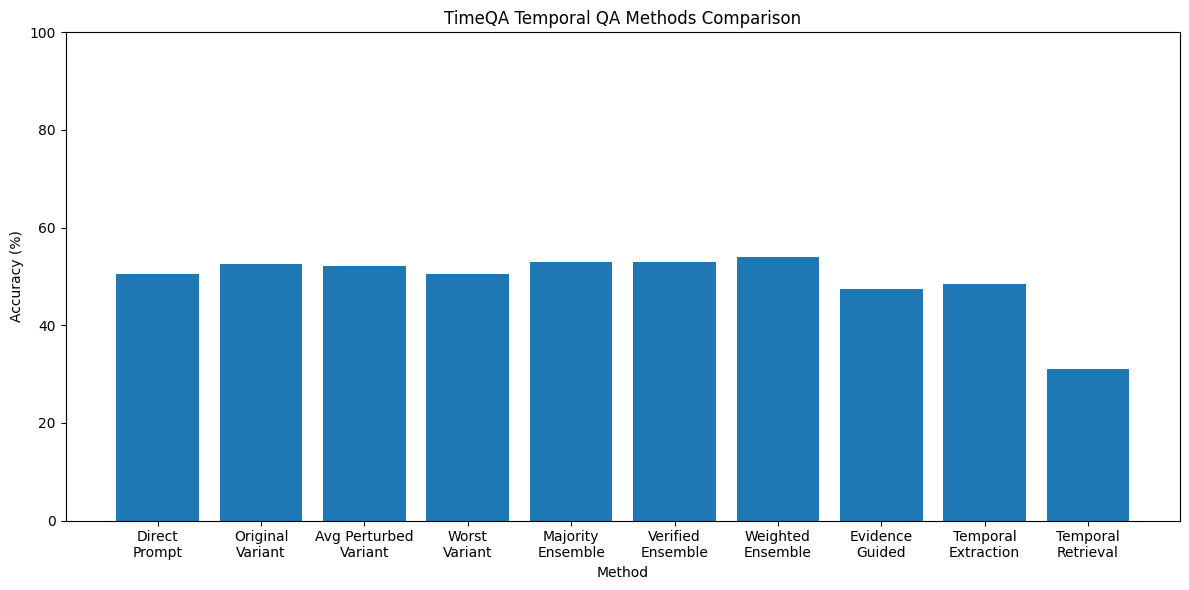

In [38]:
# ============================================================
# Plot all method accuracies
# ============================================================

plot_df = method_summary[
    ~method_summary["method"].str.contains("Oracle", case=False)
].copy()

def shorten_name(name):
    replacements = {
        "Direct Prompt Baseline": "Direct\nPrompt",
        "Original Prompt Variant": "Original\nVariant",
        "Average Perturbed Prompt Variant": "Avg Perturbed\nVariant",
        "Majority Prompt Ensemble": "Majority\nEnsemble",
        "Verified Prompt Ensemble": "Verified\nEnsemble",
        "Reliability-Weighted Prompt Ensemble": "Weighted\nEnsemble",
        "Evidence-Guided Prompting": "Evidence\nGuided",
        "Temporal Answer Extraction Prompt": "Temporal\nExtraction",
        "Temporal Evidence Retrieval Prompt": "Temporal\nRetrieval"
    }

    for k, v in replacements.items():
        if name == k:
            return v

    if name.startswith("Worst Prompt Variant"):
        return "Worst\nVariant"

    return name

plot_df["method_short"] = plot_df["method"].apply(shorten_name)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["method_short"], plot_df["accuracy_percent"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Method")
plt.title("TimeQA Temporal QA Methods Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figure_timeqa_all_methods_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

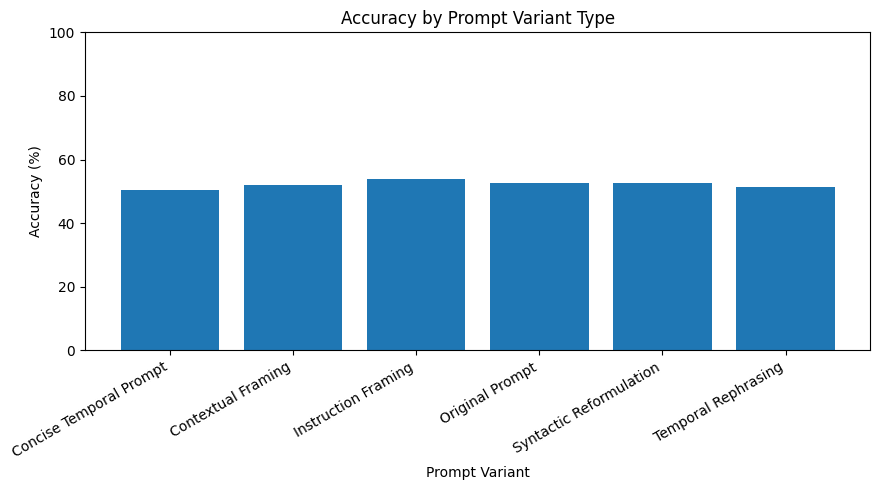

In [39]:
# ============================================================
# Plot prompt variant accuracy
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(
    accuracy_by_prompt_type["variant_type"],
    accuracy_by_prompt_type["accuracy_percent"]
)
plt.ylabel("Accuracy (%)")
plt.xlabel("Prompt Variant")
plt.title("Accuracy by Prompt Variant Type")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("figure_timeqa_prompt_variant_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# ============================================================
# Final key outputs
# ============================================================

print("=" * 80)
print("FINAL METHOD SUMMARY")
print("=" * 80)
display(method_summary)

print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
display(df_stats)

print("\n" + "=" * 80)
print("PROMPT VARIANT ACCURACY")
print("=" * 80)
display(accuracy_by_prompt_type)

print("\n" + "=" * 80)
print("KEY DIAGNOSTICS")
print("=" * 80)

print("Direct baseline accuracy:", direct_acc)
print("Majority ensemble accuracy:", majority_acc)
print("Verified ensemble accuracy:", verified_acc)
print("Evidence-guided accuracy:", evidence_acc)
print("Temporal extraction accuracy:", extraction_acc)
print("Temporal retrieval accuracy:", retrieval_acc)
print("Prompt variant oracle upper bound:", oracle_accuracy)
print("Retrieval oracle upper bound:", retrieval_oracle)

print("\nCSV files saved:")
print("- timeqa_final_method_summary.csv")
print("- timeqa_final_statistical_summary.csv")
print("- timeqa_accuracy_by_prompt_type.csv")
print("- case_analysis_direct_vs_majority.csv")
print("- case_analysis_direct_vs_verified.csv")
print("- case_analysis_direct_vs_weighted.csv")
print("- case_analysis_direct_vs_evidence_guided.csv")
print("- case_analysis_direct_vs_extraction.csv")
print("- case_analysis_direct_vs_retrieval.csv")

FINAL METHOD SUMMARY


,method,evaluation_set,accuracy,accuracy_percent
0,Direct Prompt Baseline,all,0.505,50.5
1,Original Prompt Variant,all,0.525,52.5
2,Average Perturbed Prompt Variant,all,0.521,52.1
3,Worst Prompt Variant (Concise Temporal Prompt),all,0.505,50.5
4,Majority Prompt Ensemble,all,0.530,53.0
5,Verified Prompt Ensemble,all,0.530,53.0
6,Reliability-Weighted Prompt Ensemble,held-out test half,0.540,54.0
7,Evidence-Guided Prompting,all,0.475,47.5
8,Temporal Answer Extraction Prompt,all,0.485,48.5
9,Temporal Evidence Retrieval Prompt,all,0.310,31.0



STATISTICAL SUMMARY


,method,baseline,baseline_accuracy,method_accuracy,accuracy_difference,baseline_correct_method_wrong,baseline_wrong_method_correct,mcnemar_p_value,bootstrap_mean_difference,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_diff_nonpositive
0,Majority Prompt Ensemble,Direct Baseline,0.505,0.530,0.025,3,8,0.226562,0.025118,-0.005,0.060,0.080000
1,Verified Prompt Ensemble,Direct Baseline,0.505,0.530,0.025,4,9,0.266846,0.025080,-0.010,0.060,0.106667
2,Reliability-Weighted Prompt Ensemble,Direct Baseline on held-out test half,0.500,0.540,0.040,1,5,0.218750,0.040513,0.000,0.090,0.063667
3,Evidence-Guided Prompting,Direct Baseline,0.505,0.475,-0.030,26,20,0.461391,-0.029943,-0.095,0.035,0.826667
4,Temporal Answer Extraction Prompt,Direct Baseline,0.505,0.485,-0.020,12,8,0.503445,-0.020153,-0.065,0.025,0.850000
5,Temporal Evidence Retrieval Prompt,Direct Baseline,0.505,0.310,-0.195,59,20,0.000013,-0.194952,-0.280,-0.115,1.000000



PROMPT VARIANT ACCURACY


,variant_type,correct,accuracy_percent
0,Concise Temporal Prompt,0.505,50.5
1,Contextual Framing,0.520,52.0
2,Instruction Framing,0.540,54.0
3,Original Prompt,0.525,52.5
4,Syntactic Reformulation,0.525,52.5
5,Temporal Rephrasing,0.515,51.5



KEY DIAGNOSTICS
Direct baseline accuracy: 0.505
Majority ensemble accuracy: 0.53
Verified ensemble accuracy: 0.53
Evidence-guided accuracy: 0.475
Temporal extraction accuracy: 0.485
Temporal retrieval accuracy: 0.31
Prompt variant oracle upper bound: 0.58
Retrieval oracle upper bound: 0.495

CSV files saved:
- timeqa_final_method_summary.csv
- timeqa_final_statistical_summary.csv
- timeqa_accuracy_by_prompt_type.csv
- case_analysis_direct_vs_majority.csv
- case_analysis_direct_vs_verified.csv
- case_analysis_direct_vs_weighted.csv
- case_analysis_direct_vs_evidence_guided.csv
- case_analysis_direct_vs_extraction.csv
- case_analysis_direct_vs_retrieval.csv
